In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
from pathlib import Path

In [2]:
ROOT_DIR = Path(os.getcwd()).parent

In [4]:
ticker = "AGIXBTC"
pump_ts = pd.Timestamp("2021-10-22 13:28:00")

df = pd.read_parquet(
    os.path.join(ROOT_DIR, f"data/trades/{ticker}/{ticker}-{pump_ts.year}-{pump_ts.month}.parquet")
)
df.head()

,trade_id,price,qty,time,isBuyerMaker
0,1576828,0.000007,5584.0,2021-10-01 00:00:18.005,True
1,1576829,0.000007,649.0,2021-10-01 00:00:18.005,True
2,1576830,0.000007,1568.0,2021-10-01 00:00:18.005,True
3,1576831,0.000007,87.0,2021-10-01 00:00:18.005,True
4,1576832,0.000007,333.0,2021-10-01 00:00:27.927,False


In [6]:
df["timedelta"] = df["time"].diff().dt.total_seconds().fillna(0)

cumulative_sum = df["timedelta"].cumsum()
reset_mask = cumulative_sum > 0.5
cumulative_sum = cumulative_sum - cumulative_sum.where(reset_mask).shift().fillna(0)
df["cumsum"] = cumulative_sum
df["cumsum_next"] = df["cumsum"].shift(-1)

df["is_close"] = False

df.loc[(df["cumsum"] <= 0.5) | (df["cumsum_next"] <= 0.5), "is_close"] = True

In [8]:
data = []

df_buyer_maker = df[df["isBuyerMaker"] == True].copy()
df_buyer_taker = df[df["isBuyerMaker"] == False].copy()

for time_bin, df_res in df_buyer_maker.resample("1D", on="time"):
    limit_maker_vol_ratio = df_res[df_res["is_close"] == True]["qty"].sum() / df_res["qty"].sum()
    limit_maker_num_ratio = df_res[df_res["is_close"] == True].shape[0] / df_res.shape[0]
    
    data.append({
        "time_bin": time_bin,
        "limit_maker_vol_ratio": limit_maker_vol_ratio,
        "limit_maker_num_ratio": limit_maker_num_ratio
    })
    
df_res = pd.DataFrame.from_dict(data)

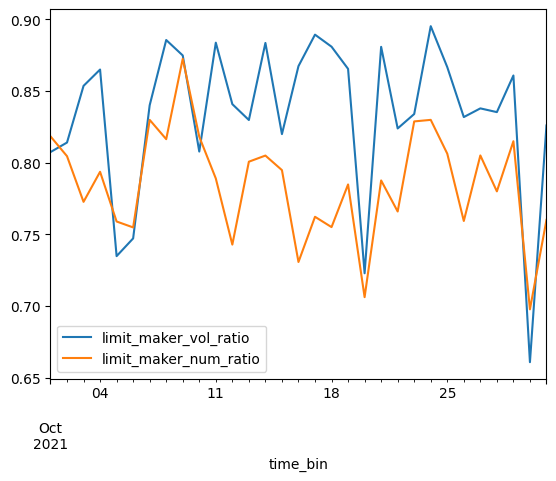

In [9]:
df_res.plot(x="time_bin", y=["limit_maker_vol_ratio", "limit_maker_num_ratio"])
plt.show()

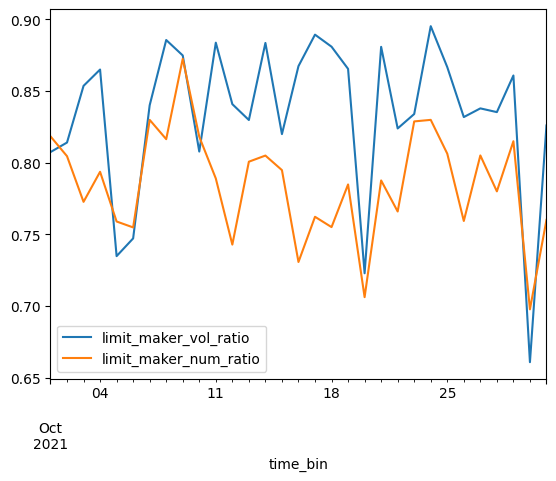

In [82]:
df_res.plot(x="time_bin", y=["limit_maker_vol_ratio", "limit_maker_num_ratio"])
plt.show()